# Diabetes Disease Classification using Machine Learning

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time
warnings.filterwarnings('ignore')

from sklearn.model_selection import (train_test_split, RandomizedSearchCV, GridSearchCV,
                                     StratifiedKFold, learning_curve)
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay,
                             f1_score, precision_recall_curve,
                             roc_auc_score, roc_curve, precision_score, recall_score)
from imblearn.over_sampling import SMOTE
from scipy.stats import uniform, randint

from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC, LinearSVC
from sklearn.calibration import CalibratedClassifierCV


from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier)

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('viridis')

# Data Loading

In [2]:
df = pd.read_csv('diabetes_prediction_dataset.csv')
df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


# Exploratory Data Analysis (EDA)

In [3]:
df.shape

(100000, 9)

In [4]:
df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


In [6]:
print(df.isnull().sum())

gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64


In [7]:
df.drop_duplicates(inplace=True)

In [8]:
df.shape

(96146, 9)

In [9]:
df.describe()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,96146.000000,96146.000000,96146.000000,96146.000000,96146.000000,96146.000000,96146.000000
mean,41.794326,0.077601,0.040803,27.321461,5.532609,138.218231,0.088220
std,22.462948,0.267544,0.197833,6.767716,1.073232,40.909771,0.283616
min,0.080000,0.000000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,24.000000,0.000000,0.000000,23.400000,4.800000,100.000000,0.000000
50%,43.000000,0.000000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,59.000000,0.000000,0.000000,29.860000,6.200000,159.000000,0.000000
max,80.000000,1.000000,1.000000,95.690000,9.000000,300.000000,1.000000


In [10]:
df.nunique()

gender                    3
age                     102
hypertension              2
heart_disease             2
smoking_history           6
bmi                    4247
HbA1c_level              18
blood_glucose_level      18
diabetes                  2
dtype: int64

In [11]:
df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


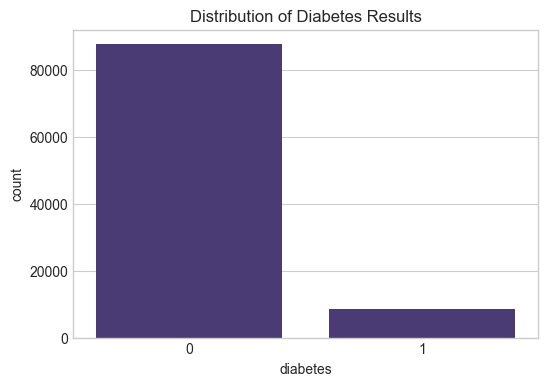

In [12]:
plt.figure(figsize=(6,4))
sns.countplot(x='diabetes', data=df)
plt.title('Distribution of Diabetes Results')
plt.show()

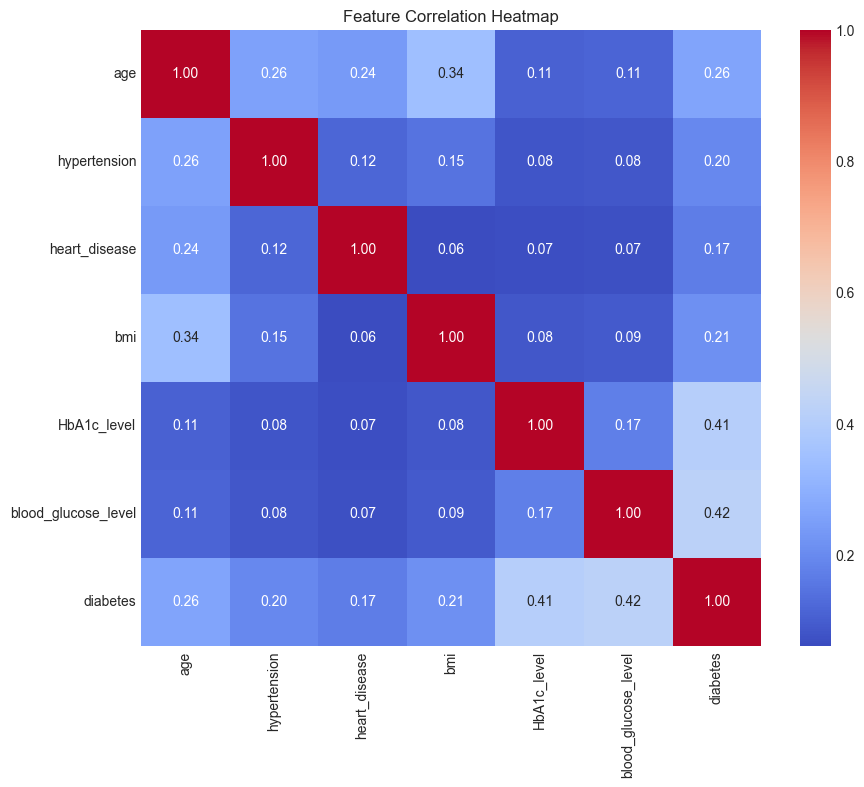

In [13]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.show()

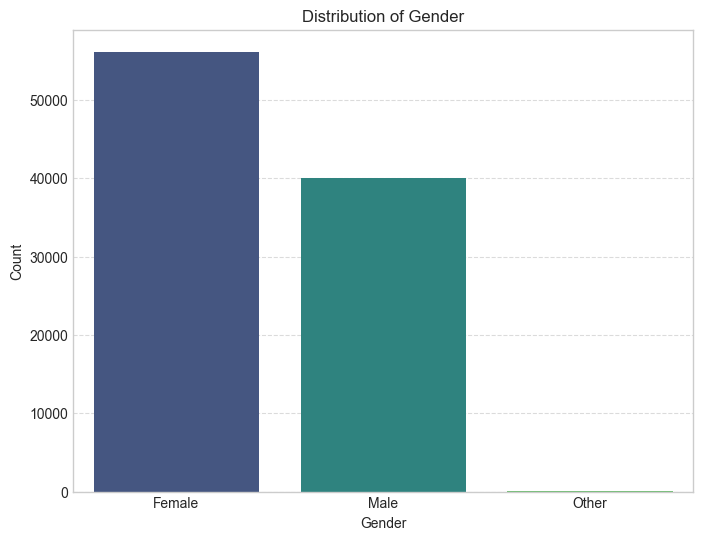

In [14]:
plt.figure(figsize=(8, 6))
sns.countplot(x='gender', data=df, palette='viridis', hue='gender', legend=False)
plt.title('Distribution of Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

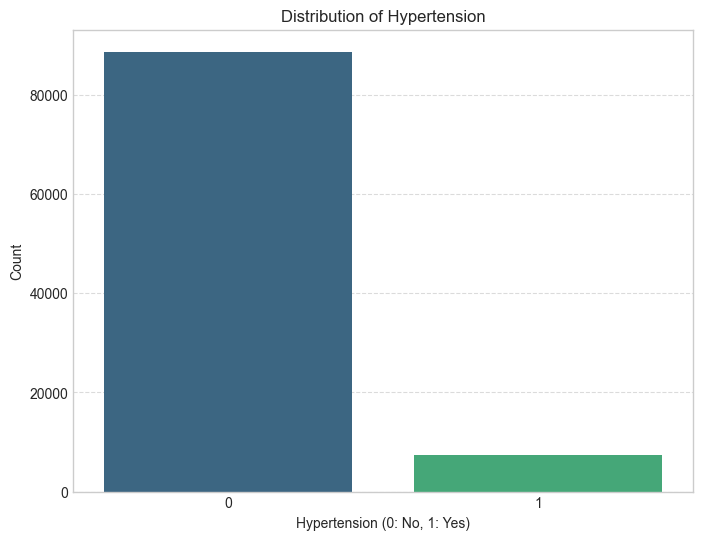

In [15]:
plt.figure(figsize=(8, 6))
sns.countplot(x='hypertension', hue='hypertension', data=df, palette='viridis', legend=False)
plt.title('Distribution of Hypertension')
plt.xlabel('Hypertension (0: No, 1: Yes)')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

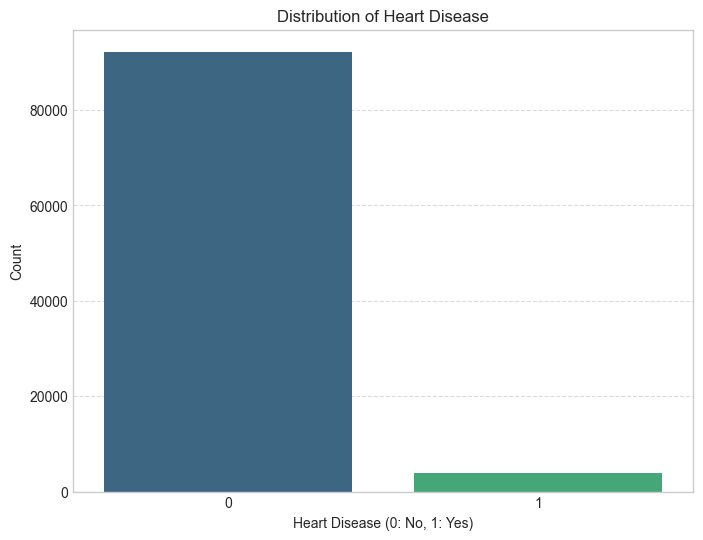

In [16]:
plt.figure(figsize=(8, 6))
sns.countplot(x='heart_disease', hue='heart_disease', data=df, palette='viridis', legend=False)
plt.title('Distribution of Heart Disease')
plt.xlabel('Heart Disease (0: No, 1: Yes)')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

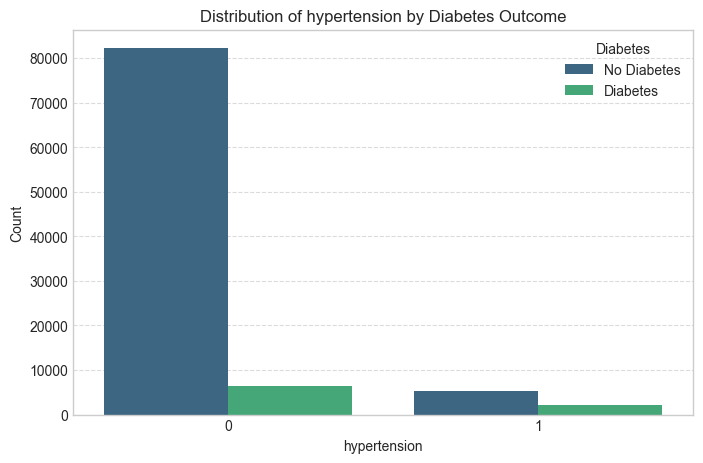

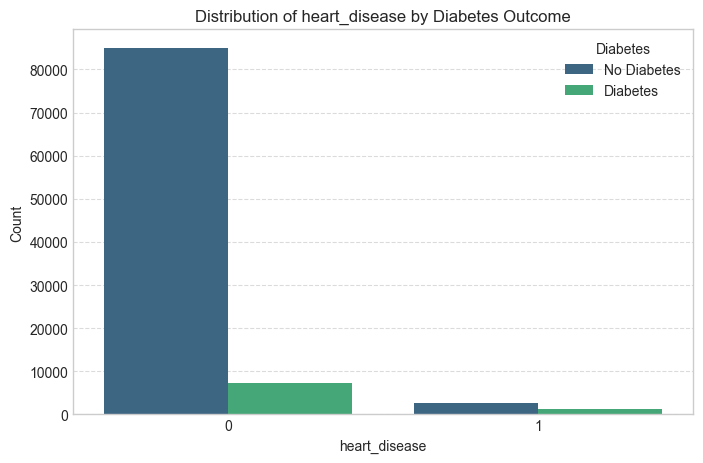

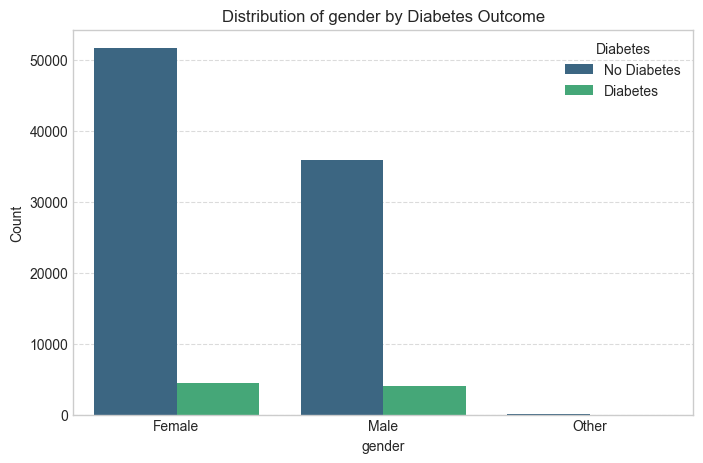

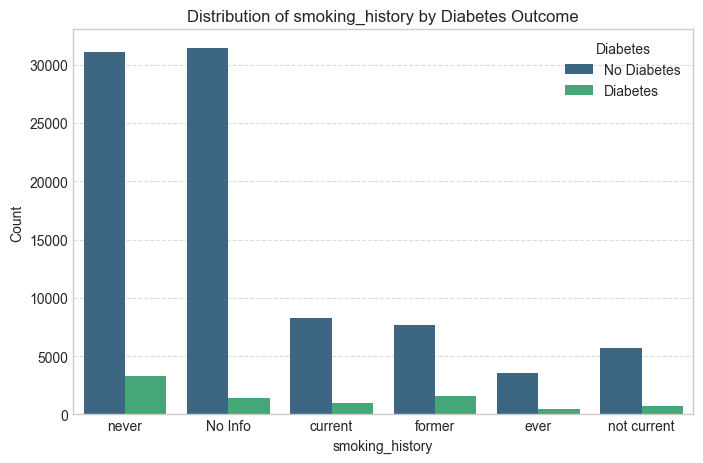

In [17]:
categorical_cols = [
    'hypertension', 'heart_disease', 'gender', 'smoking_history'
]

for col in categorical_cols:
    plt.figure(figsize=(8, 5))
    sns.countplot(x=col, hue='diabetes', data=df, palette='viridis')
    plt.title(f'Distribution of {col} by Diabetes Outcome')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.legend(title='Diabetes', labels=['No Diabetes', 'Diabetes'])
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

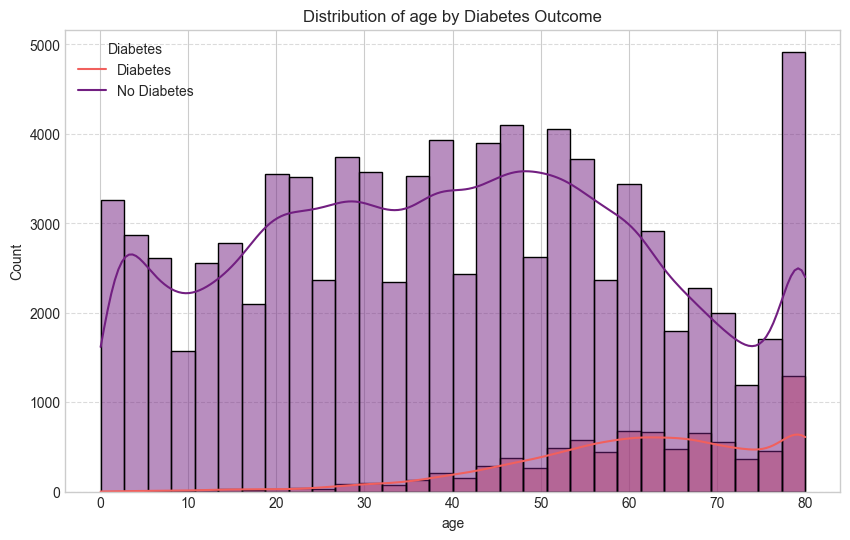

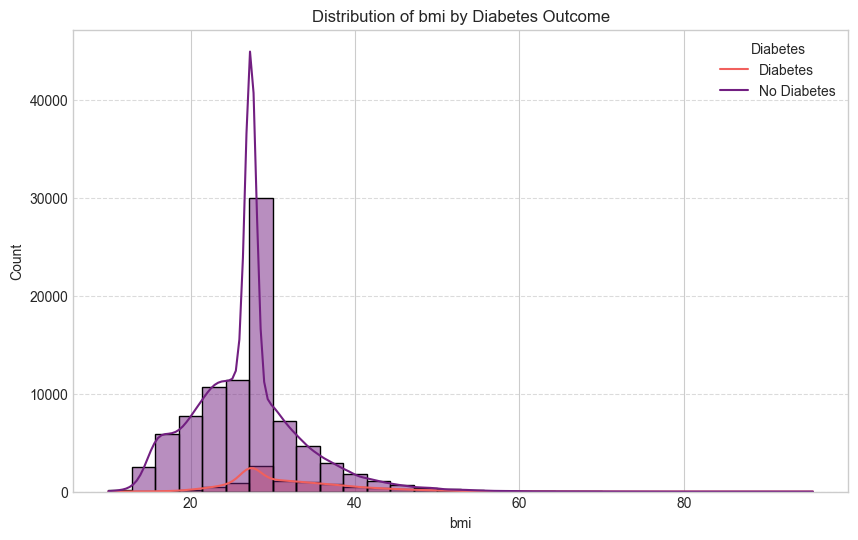

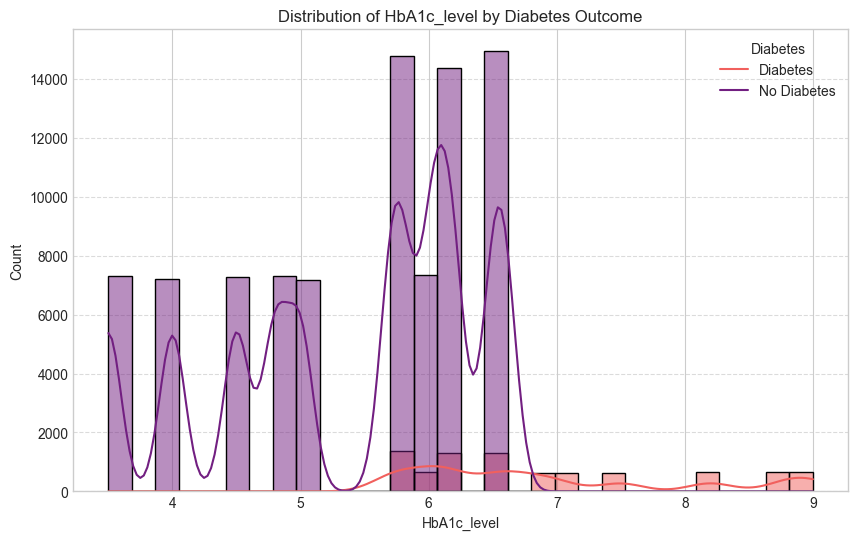

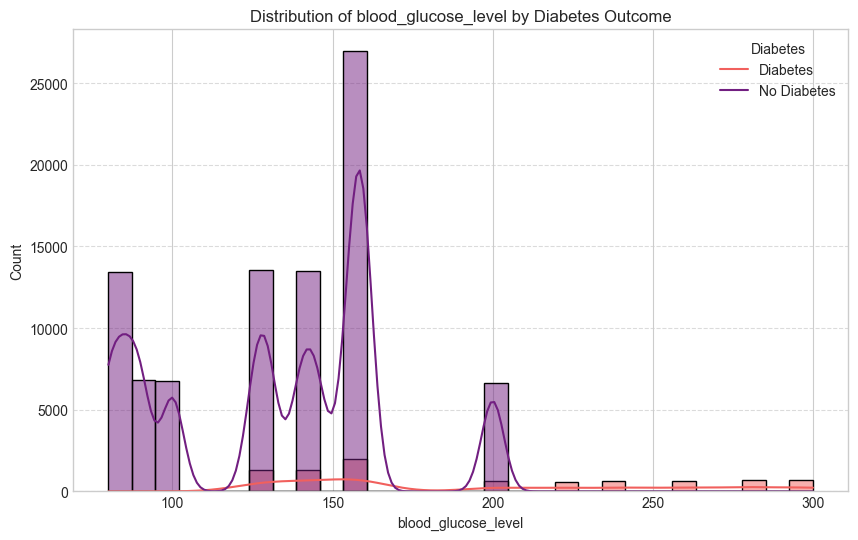

In [18]:
numerical_cols = [
    'age', 'bmi', 'HbA1c_level', 'blood_glucose_level'
]

for col in numerical_cols:
    plt.figure(figsize=(10, 6))
    sns.histplot(data=df, x=col, hue='diabetes', kde=True, palette='magma', bins=30)
    plt.title(f'Distribution of {col} by Diabetes Outcome')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.legend(title='Diabetes', labels=['Diabetes', 'No Diabetes'])
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

In [19]:
df_scatter = df.copy()
df_scatter['diabetes_status'] = df_scatter['diabetes'].map({0: 'No Diabetes', 1: 'Diabetes'})

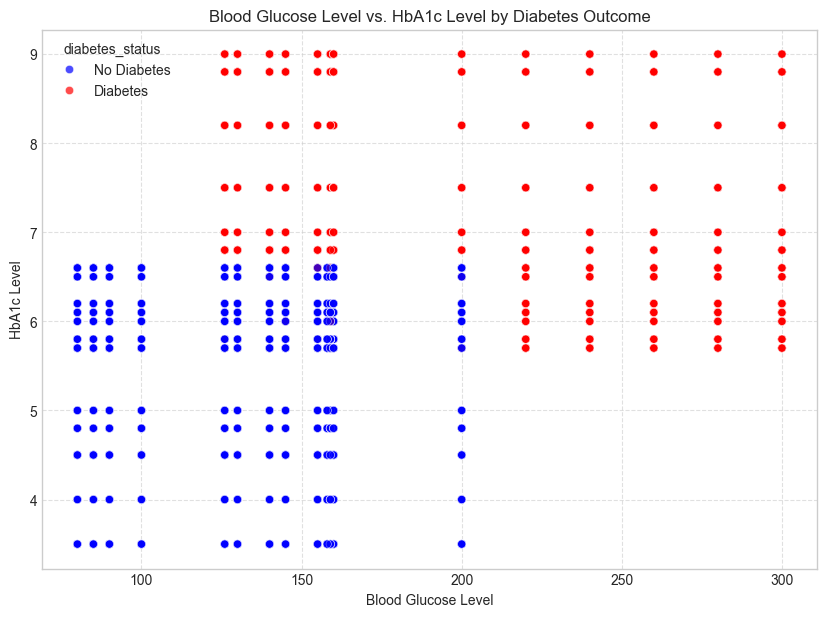

In [20]:
plt.figure(figsize=(10, 7))
sns.scatterplot(x='blood_glucose_level', y='HbA1c_level', hue='diabetes_status', data=df_scatter, palette={'No Diabetes': 'blue', 'Diabetes': 'red'}, alpha=0.7)
plt.title('Blood Glucose Level vs. HbA1c Level by Diabetes Outcome')
plt.xlabel('Blood Glucose Level')
plt.ylabel('HbA1c Level')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

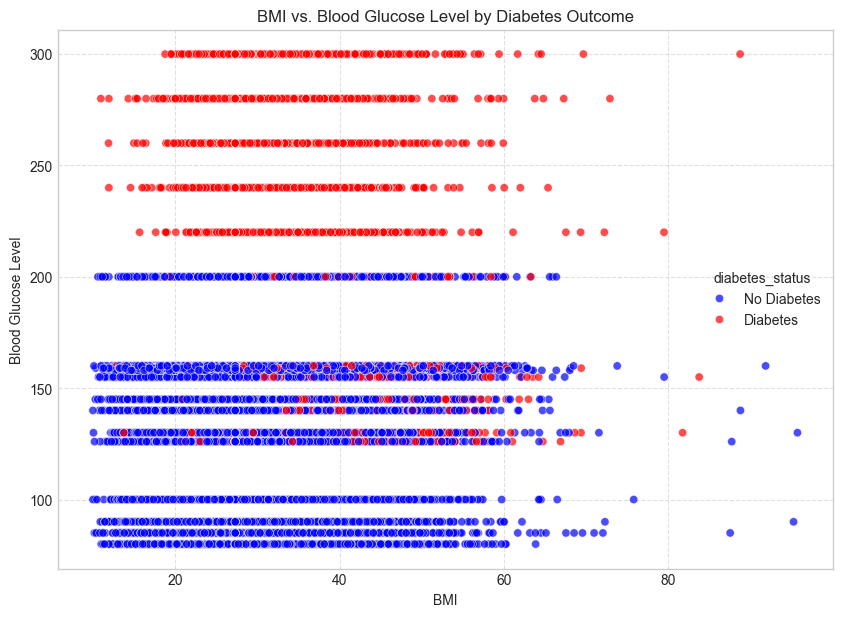

In [21]:
plt.figure(figsize=(10, 7))
sns.scatterplot(x='bmi', y='blood_glucose_level', hue='diabetes_status', data=df_scatter, palette={'No Diabetes': 'blue', 'Diabetes': 'red'}, alpha=0.7)
plt.title('BMI vs. Blood Glucose Level by Diabetes Outcome')
plt.xlabel('BMI')
plt.ylabel('Blood Glucose Level')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

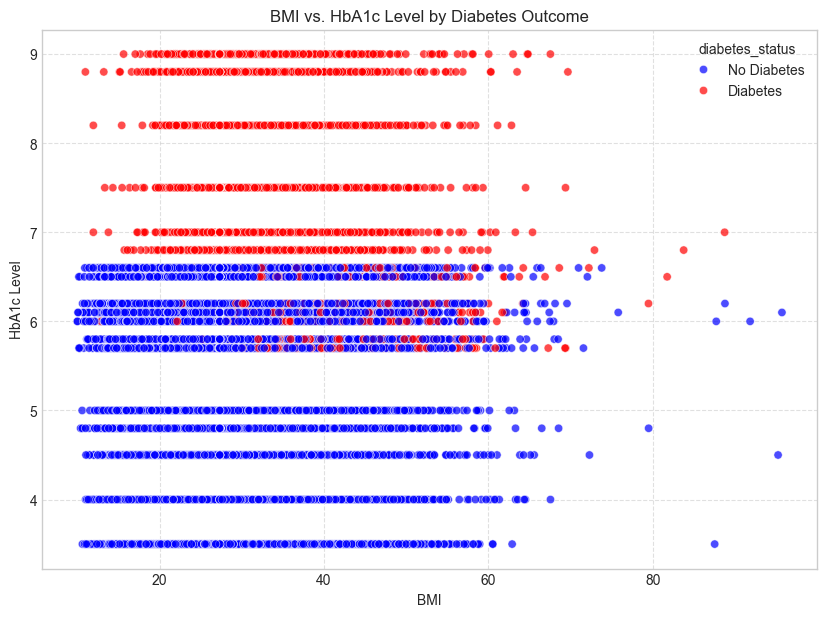

In [22]:
plt.figure(figsize=(10, 7))
sns.scatterplot(x='bmi', y='HbA1c_level', hue='diabetes_status', data=df_scatter, palette={'No Diabetes': 'blue', 'Diabetes': 'red'}, alpha=0.7)
plt.title('BMI vs. HbA1c Level by Diabetes Outcome')
plt.xlabel('BMI')
plt.ylabel('HbA1c Level')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

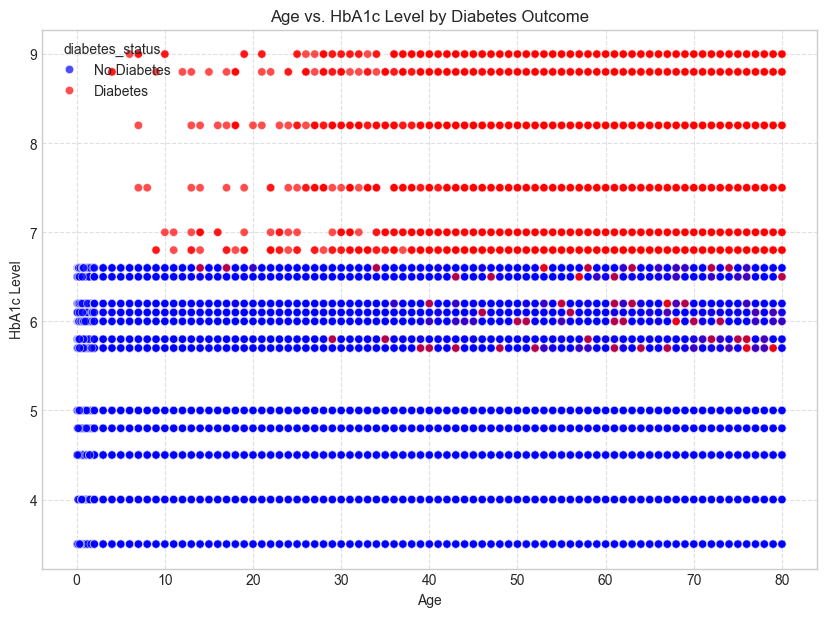

In [23]:
plt.figure(figsize=(10, 7))
sns.scatterplot(x='age', y='HbA1c_level', hue='diabetes_status', data=df_scatter, palette={'No Diabetes': 'blue', 'Diabetes': 'red'}, alpha=0.7)
plt.title('Age vs. HbA1c Level by Diabetes Outcome')
plt.xlabel('Age')
plt.ylabel('HbA1c Level')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

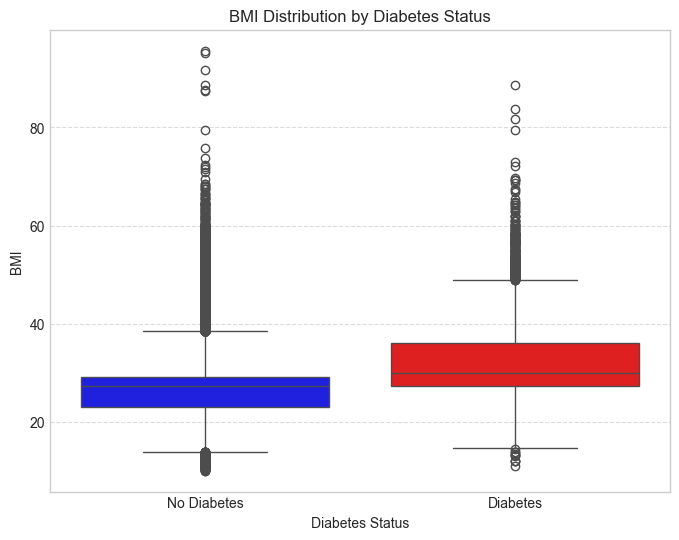

In [24]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='diabetes_status', y='bmi', hue='diabetes_status', data=df_scatter, palette={'No Diabetes': 'blue', 'Diabetes': 'red'}, legend=False)
plt.title('BMI Distribution by Diabetes Status')
plt.xlabel('Diabetes Status')
plt.ylabel('BMI')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# **Feature Engineering**

In [25]:
df = df[(df['bmi'] >= 15) & (df['bmi'] <= 35)]
df_scatter = df.copy()
df_scatter['diabetes_status'] = df_scatter['diabetes'].map({0: 'No Diabetes', 1: 'Diabetes'})

In [26]:
df.shape

(83905, 9)

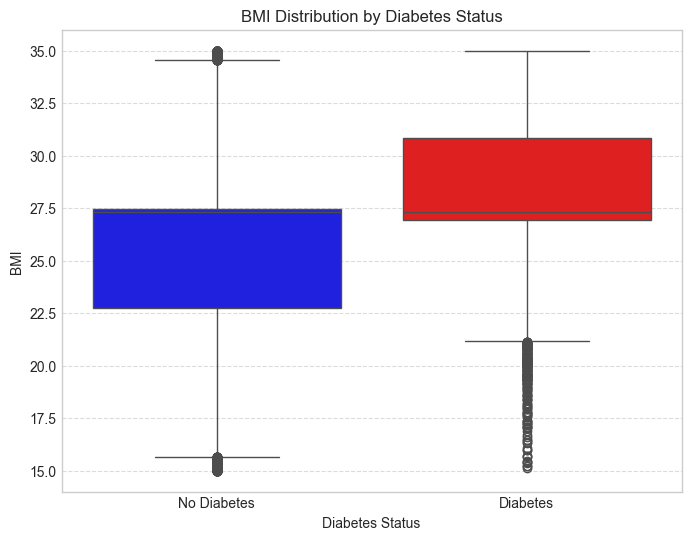

In [27]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='diabetes_status', y='bmi', hue='diabetes_status', data=df_scatter, palette={'No Diabetes': 'blue', 'Diabetes': 'red'}, legend=False)
plt.title('BMI Distribution by Diabetes Status')
plt.xlabel('Diabetes Status')
plt.ylabel('BMI')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [28]:
print(df['smoking_history'].unique())

['never' 'No Info' 'current' 'ever' 'former' 'not current']


In [29]:
df = pd.get_dummies(df, columns=['gender'])

smoking_mapping = {
    'never': 1,
    'former': 2,
    'current': 3,
    'not current': 2,
    'ever': 1,
    'No Info': 0
}
df['smoking_history'] = df['smoking_history'].map(smoking_mapping)

In [30]:
df_non_engineered = df.copy()
df['glucose_high'] = (df['blood_glucose_level'] > 140).astype(int)
df['hba1c_high'] = (df['HbA1c_level'] >= 6.5).astype(int)
df['glucose_bmi'] = df['blood_glucose_level'] * df['bmi']
df['hba1c_age'] = df['HbA1c_level'] * df['age']

def bmi_category(bmi):
    if bmi < 18.5:
        return 0
    elif bmi < 25:
        return 1
    elif bmi < 30:
        return 2
    else:
        return 3

df['bmi_cat'] = df['bmi'].apply(bmi_category)

df['age_group'] = pd.cut(
    df['age'],
    bins=[0, 30, 45, 60, 100],
    labels=[0, 1, 2, 3]
).astype(int)

df['risk_score'] = (
    (df['HbA1c_level'] >= 6.5).astype(int) +
    (df['blood_glucose_level'] > 140).astype(int) +
    (df['bmi'] > 30).astype(int)
)

# Data Splitting & Preprocessing

In [31]:
X = df.drop('diabetes', axis=1)
y = df['diabetes']


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

imbalance_ratio = y_train.value_counts()[0] / y_train.value_counts()[1]
print(f"Training set: {len(X_train)} samples")
print(f"Test set: {len(X_test)} samples")
print(f"Class imbalance ratio: {imbalance_ratio:.1f}:1")
print(f"\nTraining class distribution:\n{y_train.value_counts()}")
print(f"\nTest class distribution:\n{y_test.value_counts()}")

Training set: 67124 samples
Test set: 16781 samples
Class imbalance ratio: 12.8:1

Training class distribution:
diabetes
0    62258
1     4866
Name: count, dtype: int64

Test class distribution:
diabetes
0    15564
1     1217
Name: count, dtype: int64


# PCA (Dimensionality Reduction)

Original features: 17
PCA components: 10
Explained variance ratio: [0.26464252 0.15328278 0.11835629 0.10127738 0.08382411 0.05883193
 0.05438375 0.05269029 0.05066795 0.0301258 ]


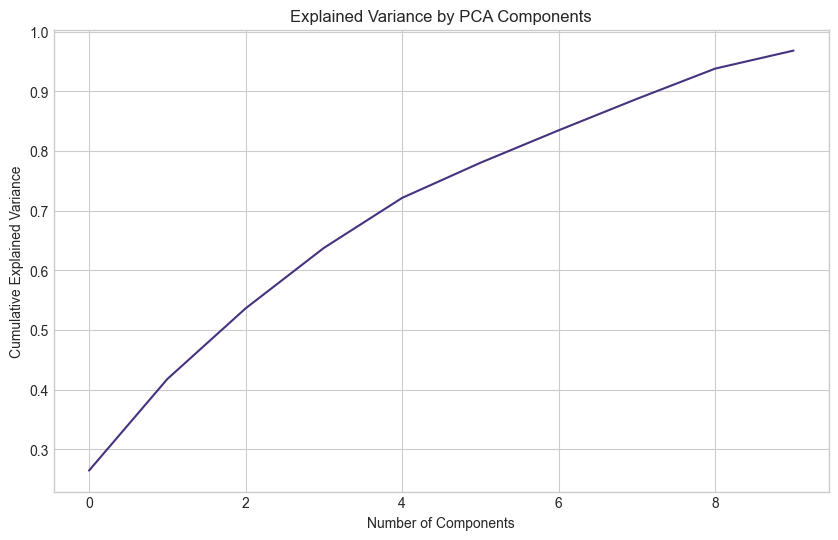

In [32]:
scaler_pca = StandardScaler()
pca = PCA(n_components=0.95)

X_train_scaled = scaler_pca.fit_transform(X_train)
X_test_scaled = scaler_pca.transform(X_test)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(f"Original features: {X_train.shape[1]}")
print(f"PCA components: {X_train_pca.shape[1]}")
print(f"Explained variance ratio: {pca.explained_variance_ratio_}")

plt.figure(figsize=(10, 6))
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance by PCA Components')
plt.grid(True)
plt.show()

# Helper Functions

In [33]:
def find_best_threshold(y_true, y_proba, n_thresholds=200):
    """Sweep thresholds and find the one maximizing F1 for Class 1."""
    thresholds = np.linspace(0.05, 0.95, n_thresholds)
    best_f1, best_t = -1, 0.5
    for t in thresholds:
        y_pred = (y_proba >= t).astype(int)
        score = f1_score(y_true, y_pred, zero_division=0)
        if score > best_f1:
            best_f1 = score
            best_t = t
    return round(best_t, 4), round(best_f1, 4)

all_results = {}

# Model Implementations

## MLP (Multi-Layer Perceptron) — With PCA

In [34]:
param_distributions_mlp = {
    'hidden_layer_sizes': [(64, 32), (32, 16), (64, 32, 16)],
    'activation': ['relu', 'tanh'],
    'solver': ['adam'],
    'alpha': uniform(0.0001, 0.01),
    'learning_rate_init': [0.001, 0.005, 0.01],
    'max_iter': [200, 300, 500],
    'batch_size': [32, 64, 128],
}

mlp_search = RandomizedSearchCV(
    estimator=MLPClassifier(random_state=42, early_stopping=True),
    param_distributions=param_distributions_mlp,
    n_iter=20,
    cv=cv_strategy,
    scoring=['f1', 'precision', 'recall'],
    refit='f1',
    verbose=2,
    random_state=42,
    n_jobs=-1
)

start = time.time()
mlp_search.fit(X_train_pca, y_train)
mlp_time = time.time() - start

best_mlp = mlp_search.best_estimator_
print(f"\nBest parameters: {mlp_search.best_params_}")
print(f"Best CV F1: {mlp_search.best_score_:.4f}")
print(f"Training time: {mlp_time:.1f}s")

Fitting 5 folds for each of 20 candidates, totalling 100 fits

Best parameters: {'activation': 'relu', 'alpha': np.float64(0.004558327528535912), 'batch_size': 128, 'hidden_layer_sizes': (64, 32, 16), 'learning_rate_init': 0.01, 'max_iter': 200, 'solver': 'adam'}
Best CV F1: 0.7894
Training time: 403.8s


Best Threshold: 0.3982
Best F1: 0.7959

Accuracy: 0.9751

Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.99     15564
           1       0.98      0.67      0.80      1217

    accuracy                           0.98     16781
   macro avg       0.98      0.83      0.89     16781
weighted avg       0.98      0.98      0.97     16781



<Figure size 600x500 with 0 Axes>

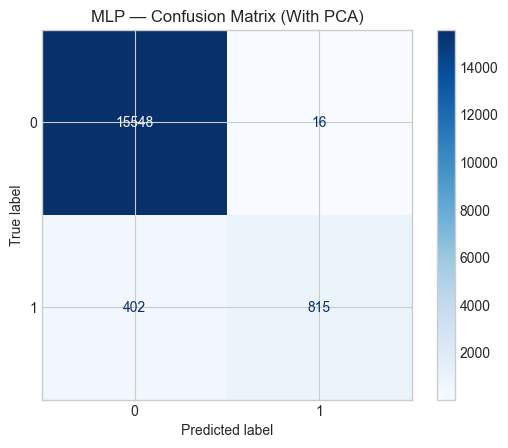

In [35]:
y_test_proba_mlp = best_mlp.predict_proba(X_test_pca)[:, 1]
best_t_mlp, best_f1_mlp = find_best_threshold(y_test, y_test_proba_mlp)

y_test_pred_mlp = (y_test_proba_mlp >= best_t_mlp).astype(int)

print(f"Best Threshold: {best_t_mlp}")
print(f"Best F1: {best_f1_mlp}")
print(f"\nAccuracy: {accuracy_score(y_test, y_test_pred_mlp):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_test_pred_mlp))

cm_mlp = confusion_matrix(y_test, y_test_pred_mlp)
plt.figure(figsize=(6,5))
ConfusionMatrixDisplay(confusion_matrix=cm_mlp).plot(cmap='Blues')
plt.title('MLP — Confusion Matrix (With PCA)')
plt.show()

all_results['MLP (PCA)'] = {
    'f1': best_f1_mlp,
    'accuracy': accuracy_score(y_test, y_test_pred_mlp),
    'threshold': best_t_mlp,
    'precision': precision_score(y_test, y_test_pred_mlp),
    'recall': recall_score(y_test, y_test_pred_mlp),
    'roc_auc': roc_auc_score(y_test, y_test_proba_mlp),
    'time': mlp_time,
    'pca': True
}

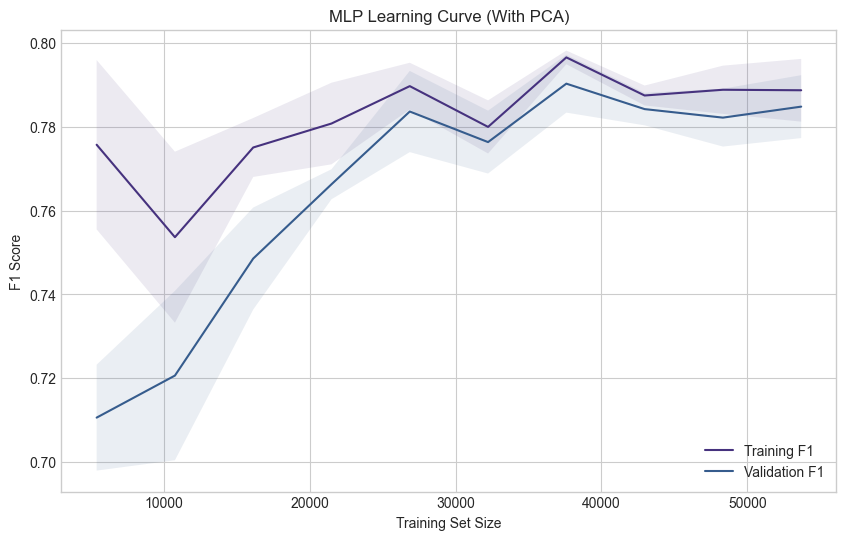

In [36]:
train_sizes, train_scores, test_scores = learning_curve(
    estimator=best_mlp, X=X_train_pca, y=y_train,
    cv=5, n_jobs=-1, train_sizes=np.linspace(0.1, 1.0, 10), scoring='f1'
)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, np.mean(train_scores, axis=1), label='Training F1')
plt.plot(train_sizes, np.mean(test_scores, axis=1), label='Validation F1')
plt.fill_between(train_sizes,
    np.mean(train_scores, axis=1) - np.std(train_scores, axis=1),
    np.mean(train_scores, axis=1) + np.std(train_scores, axis=1), alpha=0.1)
plt.fill_between(train_sizes,
    np.mean(test_scores, axis=1) - np.std(test_scores, axis=1),
    np.mean(test_scores, axis=1) + np.std(test_scores, axis=1), alpha=0.1)
plt.xlabel('Training Set Size')
plt.ylabel('F1 Score')
plt.title('MLP Learning Curve (With PCA)')
plt.legend()
plt.grid(True)
plt.show()

## Random Forest — Without PCA

In [37]:
rf_model = RandomForestClassifier(
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

param_grid_rf = {
    'n_estimators': [200, 500, 800],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf_search = RandomizedSearchCV(
    estimator=rf_model,
    param_distributions=param_grid_rf,
    n_iter=15,
    scoring=['f1', 'precision', 'recall'],
    refit='f1',
    cv=cv_strategy,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

start = time.time()
rf_search.fit(X_train, y_train)
rf_time = time.time() - start

best_rf = rf_search.best_estimator_
print(f"\nBest Parameters: {rf_search.best_params_}")
print(f"Best CV F1: {rf_search.best_score_:.4f}")
print(f"Training time: {rf_time:.1f}s")

Fitting 5 folds for each of 15 candidates, totalling 75 fits

Best Parameters: {'n_estimators': 800, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_depth': None}
Best CV F1: 0.7787
Training time: 408.7s


Best Threshold: 0.7284
Best F1: 0.7953

Accuracy: 0.9753

Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.99     15564
           1       1.00      0.66      0.80      1217

    accuracy                           0.98     16781
   macro avg       0.99      0.83      0.89     16781
weighted avg       0.98      0.98      0.97     16781



<Figure size 600x500 with 0 Axes>

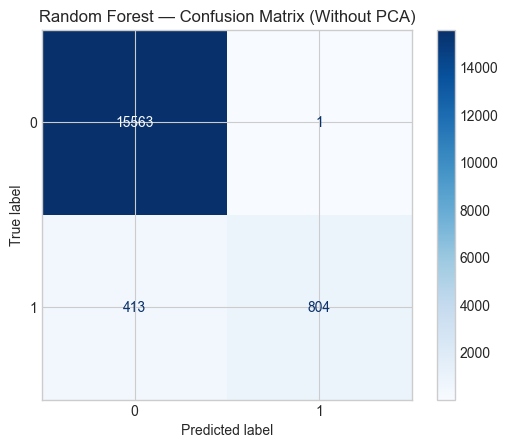


Top 15 Feature Importances:
                Feature  Importance
13            hba1c_age    0.226135
5           HbA1c_level    0.209186
6   blood_glucose_level    0.156084
12          glucose_bmi    0.131424
0                   age    0.077880
4                   bmi    0.042906
16           risk_score    0.040445
15            age_group    0.033997
11           hba1c_high    0.024026
3       smoking_history    0.016594
10         glucose_high    0.010525
1          hypertension    0.009902
14              bmi_cat    0.006397
8           gender_Male    0.005237
7         gender_Female    0.005024


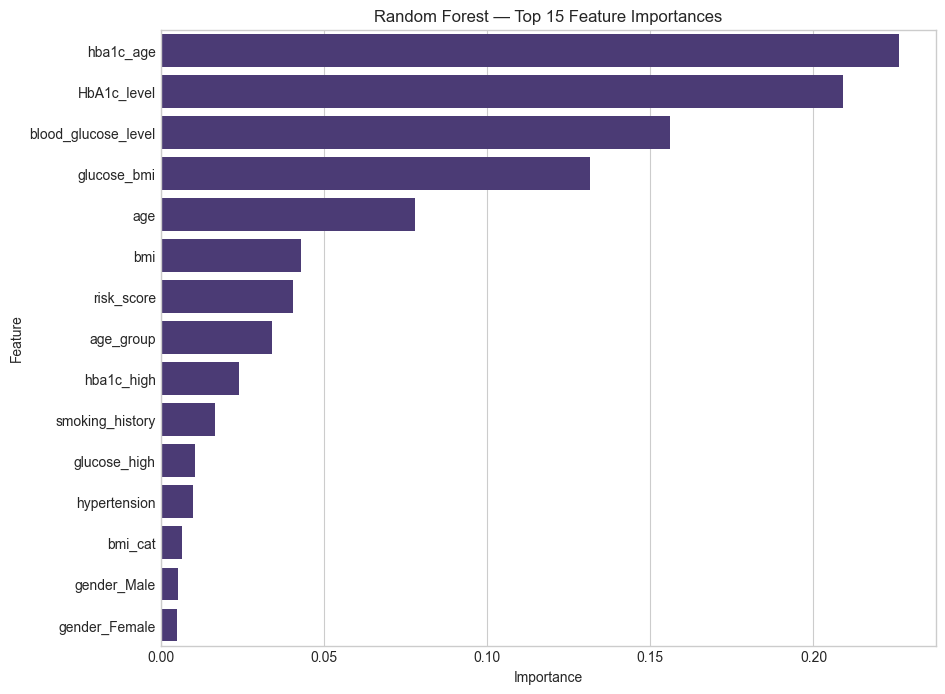

In [ ]:
y_test_probs_rf = best_rf.predict_proba(X_test)[:, 1]
best_t_rf, best_f1_rf = find_best_threshold(y_test, y_test_probs_rf)

y_test_pred_rf = (y_test_probs_rf >= best_t_rf).astype(int)

print(f"Best Threshold: {best_t_rf}")
print(f"Best F1: {best_f1_rf}")
print(f"\nAccuracy: {accuracy_score(y_test, y_test_pred_rf):.4f}")
print("\nClassification Report:")      
print(classification_report(y_test, y_test_pred_rf))

cm_rf = confusion_matrix(y_test, y_test_pred_rf)
plt.figure(figsize=(6,5))
ConfusionMatrixDisplay(confusion_matrix=cm_rf).plot(cmap='Blues')
plt.title('Random Forest — Confusion Matrix (Without PCA)')
plt.show()


feature_importance_rf = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': best_rf.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop 15 Feature Importances:")
print(feature_importance_rf.head(15))

plt.figure(figsize=(10, 8))
sns.barplot(data=feature_importance_rf.head(15), x='Importance', y='Feature')
plt.title('Random Forest — Top 15 Feature Importances')
plt.show()

all_results['Random Forest'] = {
    'f1': best_f1_rf,
    'accuracy': accuracy_score(y_test, y_test_pred_rf),
    'threshold': best_t_rf,
    'precision': precision_score(y_test, y_test_pred_rf),
    'recall': recall_score(y_test, y_test_pred_rf),
    'roc_auc': roc_auc_score(y_test, y_test_probs_rf),
    'time': rf_time,
    'pca': False
}

Exception ignored in: <_io.BytesIO object at 0x00000217DD850DB0>
Traceback (most recent call last):
  File "c:\Users\ranao\AppData\Local\Programs\Python\Python313\Lib\copy.py", line 248, in _reconstruct
    def _reconstruct(x, memo, func, args,
BufferError: Existing exports of data: object cannot be re-sized
Exception ignored in: <_io.BytesIO object at 0x00000217DA0C6840>
Traceback (most recent call last):
  File "c:\Users\ranao\AppData\Local\Programs\Python\Python313\Lib\copy.py", line 248, in _reconstruct
    def _reconstruct(x, memo, func, args,
BufferError: Existing exports of data: object cannot be re-sized


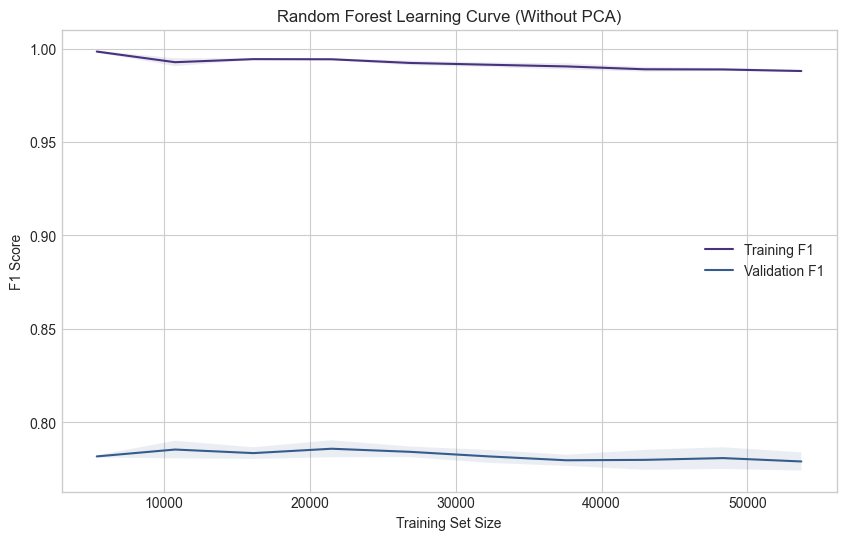

In [39]:
train_sizes, train_scores, test_scores = learning_curve(
    estimator=best_rf, X=X_train, y=y_train,
    cv=5, n_jobs=-1, train_sizes=np.linspace(0.1, 1.0, 10), scoring='f1'
)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, np.mean(train_scores, axis=1), label='Training F1')
plt.plot(train_sizes, np.mean(test_scores, axis=1), label='Validation F1')
plt.fill_between(train_sizes,
    np.mean(train_scores, axis=1) - np.std(train_scores, axis=1),
    np.mean(train_scores, axis=1) + np.std(train_scores, axis=1), alpha=0.1)
plt.fill_between(train_sizes,
    np.mean(test_scores, axis=1) - np.std(test_scores, axis=1),
    np.mean(test_scores, axis=1) + np.std(test_scores, axis=1), alpha=0.1)
plt.xlabel('Training Set Size')
plt.ylabel('F1 Score')
plt.title('Random Forest Learning Curve (Without PCA)')
plt.legend()
plt.grid(True)
plt.show()

## Gradient Boosting — Without PCA

In [40]:
gb_model = GradientBoostingClassifier(random_state=42)

param_grid_gb = {
    'n_estimators': [200, 300, 500],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 0.9, 1.0],
    'min_samples_leaf': [1, 3, 5]
}

gb_search = RandomizedSearchCV(
    estimator=gb_model,
    param_distributions=param_grid_gb,
    n_iter=15,
    scoring=['f1', 'precision', 'recall'],
    refit='f1',
    cv=cv_strategy,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

start = time.time()
gb_search.fit(X_train, y_train)
gb_time = time.time() - start

best_gb = gb_search.best_estimator_
print(f"\nBest Parameters: {gb_search.best_params_}")
print(f"Best CV F1: {gb_search.best_score_:.4f}")
print(f"Training time: {gb_time:.1f}s")

Fitting 5 folds for each of 15 candidates, totalling 75 fits


Exception ignored in: <_io.BytesIO object at 0x00000217DD841AD0>
Traceback (most recent call last):
  File "C:\Users\ranao\AppData\Roaming\Python\Python313\site-packages\debugpy\_vendored\pydevd\_pydevd_bundle\pydevd_filtering.py", line 315, in exclude_by_filter
    def exclude_by_filter(self, absolute_filename, module_name):
BufferError: Existing exports of data: object cannot be re-sized



Best Parameters: {'subsample': 0.8, 'n_estimators': 500, 'min_samples_leaf': 5, 'max_depth': 3, 'learning_rate': 0.01}
Best CV F1: 0.8012
Training time: 298.8s


Best Threshold: 0.3214
Best F1: 0.7982

Accuracy: 0.9753

Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99     15564
           1       0.98      0.67      0.80      1217

    accuracy                           0.98     16781
   macro avg       0.98      0.84      0.89     16781
weighted avg       0.98      0.98      0.97     16781



<Figure size 600x500 with 0 Axes>

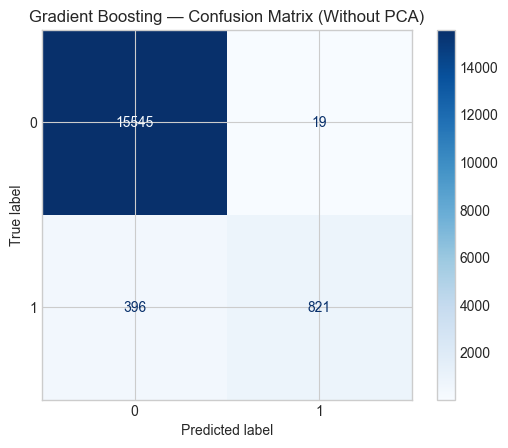


Top 15 Feature Importances:
                Feature    Importance
5           HbA1c_level  6.384110e-01
6   blood_glucose_level  3.148040e-01
13            hba1c_age  3.173372e-02
12          glucose_bmi  9.444437e-03
1          hypertension  2.681527e-03
2         heart_disease  1.294875e-03
4                   bmi  9.852595e-04
3       smoking_history  5.284260e-04
0                   age  9.124577e-05
16           risk_score  2.551478e-05
14              bmi_cat  4.629783e-15
7         gender_Female  4.362766e-20
11           hba1c_high  0.000000e+00
9          gender_Other  0.000000e+00
10         glucose_high  0.000000e+00


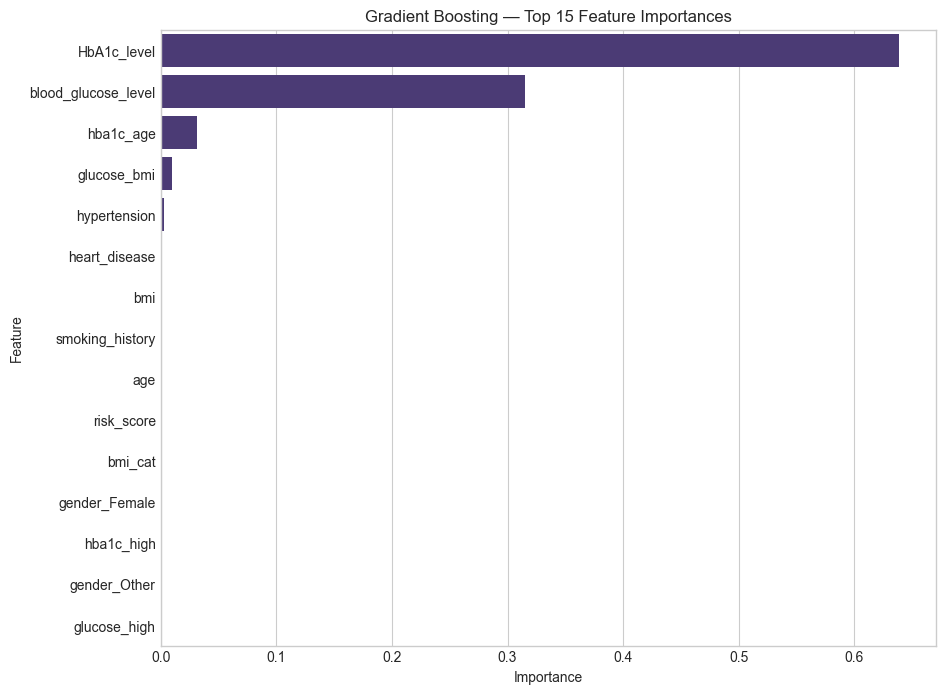

In [41]:
y_test_probs_gb = best_gb.predict_proba(X_test)[:, 1]
best_t_gb, best_f1_gb = find_best_threshold(y_test, y_test_probs_gb)

y_test_pred_gb = (y_test_probs_gb >= best_t_gb).astype(int)

print(f"Best Threshold: {best_t_gb}")
print(f"Best F1: {best_f1_gb}")
print(f"\nAccuracy: {accuracy_score(y_test, y_test_pred_gb):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_test_pred_gb))

cm_gb = confusion_matrix(y_test, y_test_pred_gb)
plt.figure(figsize=(6,5))
ConfusionMatrixDisplay(confusion_matrix=cm_gb).plot(cmap='Blues')
plt.title('Gradient Boosting — Confusion Matrix (Without PCA)')
plt.show()


feature_importance_gb = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': best_gb.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop 15 Feature Importances:")
print(feature_importance_gb.head(15))

plt.figure(figsize=(10, 8))
sns.barplot(data=feature_importance_gb.head(15), x='Importance', y='Feature')
plt.title('Gradient Boosting — Top 15 Feature Importances')
plt.show()

all_results['Gradient Boosting'] = {
    'f1': best_f1_gb,
    'accuracy': accuracy_score(y_test, y_test_pred_gb),
    'threshold': best_t_gb,
    'precision': precision_score(y_test, y_test_pred_gb),
    'recall': recall_score(y_test, y_test_pred_gb),
    'roc_auc': roc_auc_score(y_test, y_test_probs_gb),
    'time': gb_time,
    'pca': False
}

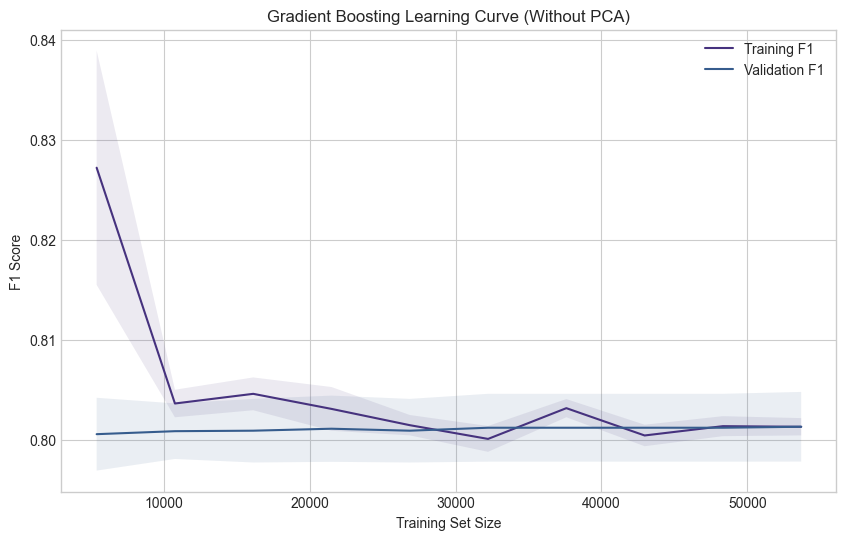

In [42]:
train_sizes, train_scores, test_scores = learning_curve(
    estimator=best_gb, X=X_train, y=y_train,
    cv=5, n_jobs=-1, train_sizes=np.linspace(0.1, 1.0, 10), scoring='f1'
)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, np.mean(train_scores, axis=1), label='Training F1')
plt.plot(train_sizes, np.mean(test_scores, axis=1), label='Validation F1')
plt.fill_between(train_sizes,
    np.mean(train_scores, axis=1) - np.std(train_scores, axis=1),
    np.mean(train_scores, axis=1) + np.std(train_scores, axis=1), alpha=0.1)
plt.fill_between(train_sizes,
    np.mean(test_scores, axis=1) - np.std(test_scores, axis=1),
    np.mean(test_scores, axis=1) + np.std(test_scores, axis=1), alpha=0.1)
plt.xlabel('Training Set Size')
plt.ylabel('F1 Score')
plt.title('Gradient Boosting Learning Curve (Without PCA)')
plt.legend()
plt.grid(True)
plt.show()

## Logistic Regression — With PCA

In [43]:
param_distributions_lr = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear'],
    'class_weight': [{0: 1, 1: 3}, {0: 1, 1: 4}, {0: 1, 1: 5}, 'balanced'],
    'max_iter': [2000],
}

lr_search = RandomizedSearchCV(
    estimator=LogisticRegression(random_state=42),
    param_distributions=param_distributions_lr,
    n_iter=20,
    cv=cv_strategy,
    scoring=['f1', 'precision', 'recall'],
    refit='f1',
    verbose=2,
    random_state=42,
    n_jobs=-1
)

start = time.time()
lr_search.fit(X_train_pca, y_train)
lr_time = time.time() - start

best_lr = lr_search.best_estimator_
print(f"\nBest parameters: {lr_search.best_params_}")
print(f"Best CV F1: {lr_search.best_score_:.4f}")
print(f"Training time: {lr_time:.1f}s")

Fitting 5 folds for each of 20 candidates, totalling 100 fits

Best parameters: {'solver': 'liblinear', 'penalty': 'l2', 'max_iter': 2000, 'class_weight': {0: 1, 1: 3}, 'C': 0.01}
Best CV F1: 0.6970
Training time: 3.0s


Best Threshold: 0.6786
Best F1: 0.7139

Accuracy: 0.9644

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98     15564
           1       0.85      0.61      0.71      1217

    accuracy                           0.96     16781
   macro avg       0.91      0.80      0.85     16781
weighted avg       0.96      0.96      0.96     16781



<Figure size 600x500 with 0 Axes>

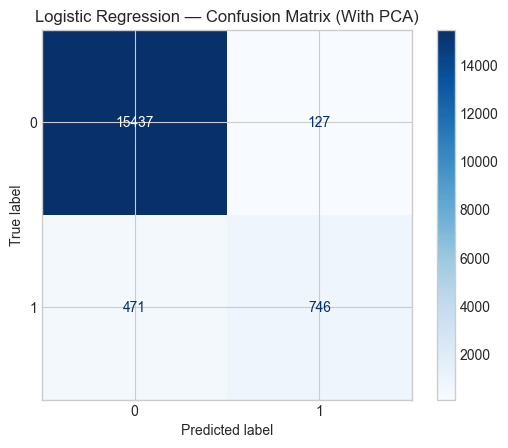

In [44]:
y_test_proba_lr = best_lr.predict_proba(X_test_pca)[:, 1]
best_t_lr, best_f1_lr = find_best_threshold(y_test, y_test_proba_lr)

y_test_pred_lr = (y_test_proba_lr >= best_t_lr).astype(int)

print(f"Best Threshold: {best_t_lr}")
print(f"Best F1: {best_f1_lr}")
print(f"\nAccuracy: {accuracy_score(y_test, y_test_pred_lr):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_test_pred_lr))

cm_lr = confusion_matrix(y_test, y_test_pred_lr)
plt.figure(figsize=(6,5))
ConfusionMatrixDisplay(confusion_matrix=cm_lr).plot(cmap='Blues')
plt.title('Logistic Regression — Confusion Matrix (With PCA)')
plt.show()

all_results['Logistic Regression (PCA)'] = {
    'f1': best_f1_lr,
    'accuracy': accuracy_score(y_test, y_test_pred_lr),
    'threshold': best_t_lr,
    'precision': precision_score(y_test, y_test_pred_lr),
    'recall': recall_score(y_test, y_test_pred_lr),
    'roc_auc': roc_auc_score(y_test, y_test_proba_lr),
    'time': lr_time,
    'pca': True
}

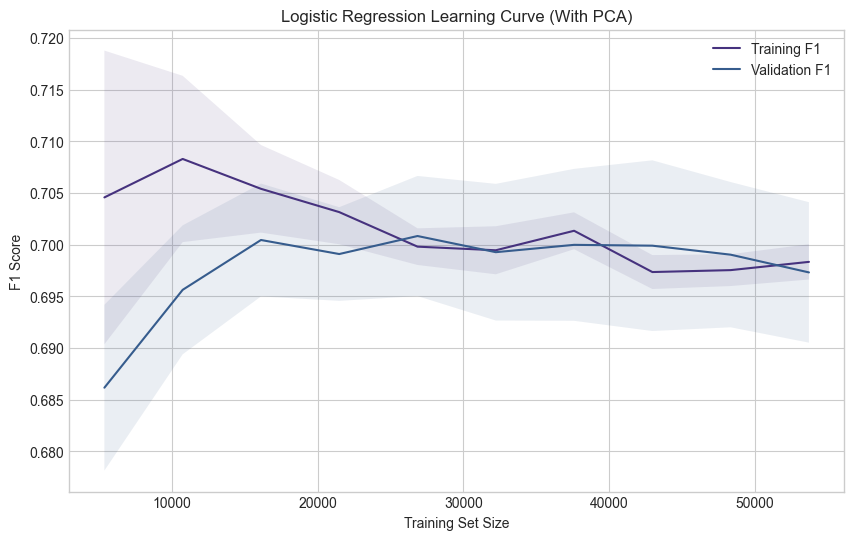

In [45]:
train_sizes, train_scores, test_scores = learning_curve(
    estimator=best_lr, X=X_train_pca, y=y_train,
    cv=5, n_jobs=-1, train_sizes=np.linspace(0.1, 1.0, 10), scoring='f1'
)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, np.mean(train_scores, axis=1), label='Training F1')
plt.plot(train_sizes, np.mean(test_scores, axis=1), label='Validation F1')
plt.fill_between(train_sizes,
    np.mean(train_scores, axis=1) - np.std(train_scores, axis=1),
    np.mean(train_scores, axis=1) + np.std(train_scores, axis=1), alpha=0.1)
plt.fill_between(train_sizes,
    np.mean(test_scores, axis=1) - np.std(test_scores, axis=1),
    np.mean(test_scores, axis=1) + np.std(test_scores, axis=1), alpha=0.1)
plt.xlabel('Training Set Size')
plt.ylabel('F1 Score')
plt.title('Logistic Regression Learning Curve (With PCA)')
plt.legend()
plt.grid(True)
plt.show()

## Naive Bayes (Gaussian) — With PCA

In [46]:
param_distributions_nb = {
    'var_smoothing': np.logspace(0, -9, num=30),
}

nb_search = RandomizedSearchCV(
    estimator=GaussianNB(),
    param_distributions=param_distributions_nb,
    n_iter=20,
    cv=cv_strategy,
    scoring=['f1', 'precision', 'recall'],
    refit='f1',
    verbose=2,
    random_state=42,
    n_jobs=-1
)

start = time.time()
nb_search.fit(X_train_pca, y_train)
nb_time = time.time() - start

best_nb = nb_search.best_estimator_
print(f"\nBest parameters: {nb_search.best_params_}")
print(f"Best CV F1: {nb_search.best_score_:.4f}")
print(f"Training time: {nb_time:.1f}s")

Fitting 5 folds for each of 20 candidates, totalling 100 fits

Best parameters: {'var_smoothing': np.float64(0.117210229753348)}
Best CV F1: 0.5475
Training time: 0.8s


Best Threshold: 0.3033
Best F1: 0.5719

Accuracy: 0.9289

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.95      0.96     15564
           1       0.51      0.65      0.57      1217

    accuracy                           0.93     16781
   macro avg       0.74      0.80      0.77     16781
weighted avg       0.94      0.93      0.93     16781



<Figure size 600x500 with 0 Axes>

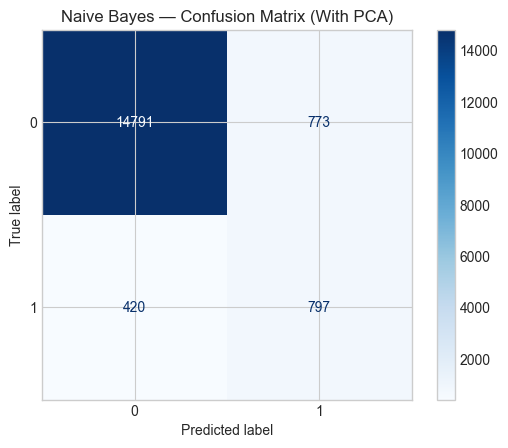

In [47]:
y_test_proba_nb = best_nb.predict_proba(X_test_pca)[:, 1]
best_t_nb, best_f1_nb = find_best_threshold(y_test, y_test_proba_nb)

y_test_pred_nb = (y_test_proba_nb >= best_t_nb).astype(int)

print(f"Best Threshold: {best_t_nb}")
print(f"Best F1: {best_f1_nb}")
print(f"\nAccuracy: {accuracy_score(y_test, y_test_pred_nb):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_test_pred_nb))

cm_nb = confusion_matrix(y_test, y_test_pred_nb)
plt.figure(figsize=(6,5))
ConfusionMatrixDisplay(confusion_matrix=cm_nb).plot(cmap='Blues')
plt.title('Naive Bayes — Confusion Matrix (With PCA)')
plt.show()

all_results['Naive Bayes (PCA)'] = {
    'f1': best_f1_nb,
    'accuracy': accuracy_score(y_test, y_test_pred_nb),
    'threshold': best_t_nb,
    'precision': precision_score(y_test, y_test_pred_nb),
    'recall': recall_score(y_test, y_test_pred_nb),
    'roc_auc': roc_auc_score(y_test, y_test_proba_nb),
    'time': nb_time,
    'pca': True
}

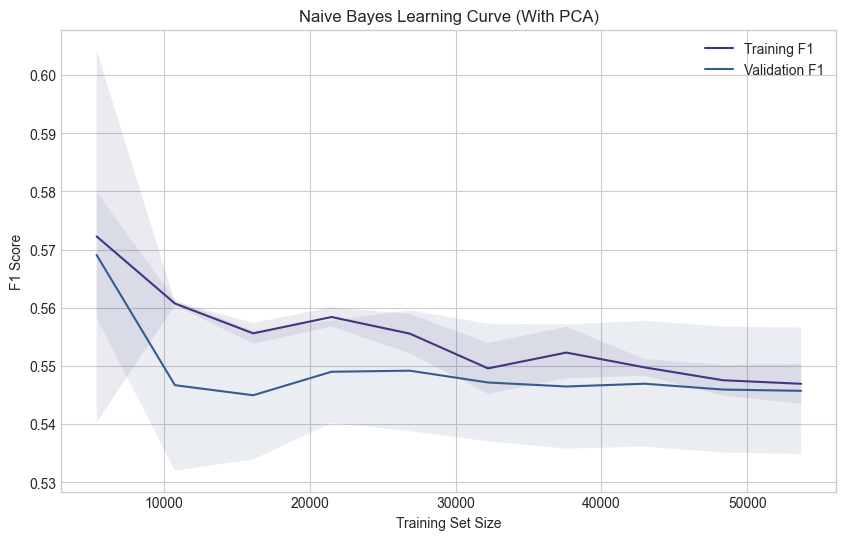

In [48]:
train_sizes, train_scores, test_scores = learning_curve(
    estimator=best_nb, X=X_train_pca, y=y_train,
    cv=5, n_jobs=-1, train_sizes=np.linspace(0.1, 1.0, 10), scoring='f1'
)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, np.mean(train_scores, axis=1), label='Training F1')
plt.plot(train_sizes, np.mean(test_scores, axis=1), label='Validation F1')
plt.fill_between(train_sizes,
    np.mean(train_scores, axis=1) - np.std(train_scores, axis=1),
    np.mean(train_scores, axis=1) + np.std(train_scores, axis=1), alpha=0.1)
plt.fill_between(train_sizes,
    np.mean(test_scores, axis=1) - np.std(test_scores, axis=1),
    np.mean(test_scores, axis=1) + np.std(test_scores, axis=1), alpha=0.1)
plt.xlabel('Training Set Size')
plt.ylabel('F1 Score')
plt.title('Naive Bayes Learning Curve (With PCA)')
plt.legend()
plt.grid(True)
plt.show()

## SVM (Support Vector Machine) — With Scaled Data

### SVM — Linear Kernel

In [49]:
linear_svm = CalibratedClassifierCV(
    LinearSVC(random_state=42, class_weight='balanced', max_iter=5000, dual='auto')
)

param_grid_lsvm = {
    'estimator__C': [0.001, 0.01, 0.1, 1, 10]
}

lsvm_search = RandomizedSearchCV(
    estimator=linear_svm,
    param_distributions=param_grid_lsvm,
    n_iter=5,
    scoring=['f1', 'precision', 'recall'],
    refit='f1',
    cv=cv_strategy,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

start = time.time()
lsvm_search.fit(X_train_scaled, y_train)
lsvm_time = time.time() - start

best_lsvm = lsvm_search.best_estimator_
print(f"\nBest Parameters: {lsvm_search.best_params_}")
print(f"Best CV F1: {lsvm_search.best_score_:.4f}")
print(f"Training time: {lsvm_time:.1f}s")

Fitting 5 folds for each of 5 candidates, totalling 25 fits

Best Parameters: {'estimator__C': 0.1}
Best CV F1: 0.7232
Training time: 6.4s


Best Threshold: 0.4028
Best F1: 0.7186

Accuracy: 0.9636

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98     15564
           1       0.82      0.64      0.72      1217

    accuracy                           0.96     16781
   macro avg       0.90      0.81      0.85     16781
weighted avg       0.96      0.96      0.96     16781



<Figure size 600x500 with 0 Axes>

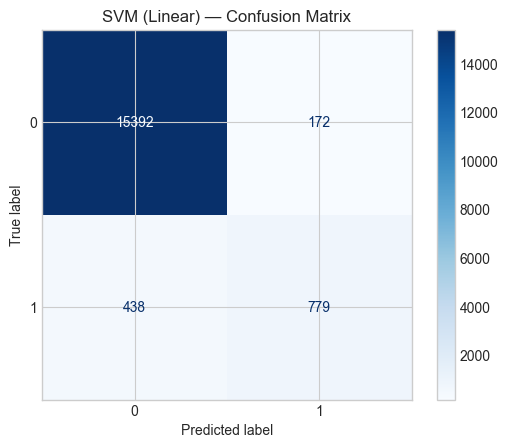

In [50]:
y_test_proba_lsvm = best_lsvm.predict_proba(X_test_scaled)[:, 1]
best_t_lsvm, best_f1_lsvm = find_best_threshold(y_test, y_test_proba_lsvm)

y_test_pred_lsvm = (y_test_proba_lsvm >= best_t_lsvm).astype(int)

print(f"Best Threshold: {best_t_lsvm}")
print(f"Best F1: {best_f1_lsvm}")
print(f"\nAccuracy: {accuracy_score(y_test, y_test_pred_lsvm):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_test_pred_lsvm))

cm_lsvm = confusion_matrix(y_test, y_test_pred_lsvm)
plt.figure(figsize=(6,5))
ConfusionMatrixDisplay(confusion_matrix=cm_lsvm).plot(cmap='Blues')
plt.title('SVM (Linear) — Confusion Matrix')
plt.show()

all_results['SVM (Linear)'] = {
    'f1': best_f1_lsvm,
    'accuracy': accuracy_score(y_test, y_test_pred_lsvm),
    'threshold': best_t_lsvm,
    'precision': precision_score(y_test, y_test_pred_lsvm),
    'recall': recall_score(y_test, y_test_pred_lsvm),
    'roc_auc': roc_auc_score(y_test, y_test_proba_lsvm),
    'time': lsvm_time,
    'pca': False
}

### SVM — RBF Kernel (Grid Search)

In [51]:
rbf_svm = SVC(kernel='rbf', class_weight='balanced', random_state=42, probability=True)

param_grid_rbf = {
    'C': [0.1, 1, 10, 100],
    'gamma': [0.001, 0.01, 0.1, 1]
}


rbf_grid_search = GridSearchCV(
    estimator=rbf_svm,
    param_grid=param_grid_rbf,
    scoring='f1',
    cv=cv_strategy,
    verbose=2,
    n_jobs=-1
)

start = time.time()
rbf_grid_search.fit(X_train_scaled, y_train)
rbf_grid_time = time.time() - start

best_rbf_grid = rbf_grid_search.best_estimator_
print(f"\nGrid Search Best Parameters: {rbf_grid_search.best_params_}")
print(f"Grid Search Best CV F1: {rbf_grid_search.best_score_:.4f}")
print(f"Training time: {rbf_grid_time:.1f}s")

Fitting 5 folds for each of 16 candidates, totalling 80 fits


KeyboardInterrupt: 

In [ ]:
y_test_proba_rbf_grid = best_rbf_grid.predict_proba(X_test_scaled)[:, 1]
best_t_rbf_grid, best_f1_rbf_grid = find_best_threshold(y_test, y_test_proba_rbf_grid)

y_test_pred_rbf_grid = (y_test_proba_rbf_grid >= best_t_rbf_grid).astype(int)

print(f"Best Threshold: {best_t_rbf_grid}")
print(f"Best F1: {best_f1_rbf_grid}")
print(f"\nAccuracy: {accuracy_score(y_test, y_test_pred_rbf_grid):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_test_pred_rbf_grid))

cm_rbf_grid = confusion_matrix(y_test, y_test_pred_rbf_grid)
plt.figure(figsize=(6,5))
ConfusionMatrixDisplay(confusion_matrix=cm_rbf_grid).plot(cmap='Blues')
plt.title('SVM (RBF) Grid Search — Confusion Matrix')
plt.show()

all_results['SVM (RBF) GridSearch'] = {
    'f1': best_f1_rbf_grid,
    'accuracy': accuracy_score(y_test, y_test_pred_rbf_grid),
    'threshold': best_t_rbf_grid,
    'precision': precision_score(y_test, y_test_pred_rbf_grid),
    'recall': recall_score(y_test, y_test_pred_rbf_grid),
    'roc_auc': roc_auc_score(y_test, y_test_proba_rbf_grid),
    'time': rbf_grid_time,
    'pca': False
}

### SVM — RBF Kernel (Particle Swarm Optimization)

In [ ]:
def pso_svm(X_train, y_train, cv_strategy, n_particles=15, n_iterations=20,
            c_range=(0.01, 100), gamma_range=(0.001, 1), random_state=42):
    """
    PSO to find optimal C and gamma for SVM RBF kernel.
    Each particle = [C, gamma] in log-space.
    Fitness = mean CV F1 score.
    """
    np.random.seed(random_state)

    # Initialize particles in log-space
    particles = np.column_stack([
        np.random.uniform(np.log10(c_range[0]), np.log10(c_range[1]), n_particles),
        np.random.uniform(np.log10(gamma_range[0]), np.log10(gamma_range[1]), n_particles)
    ])
    velocities = np.random.uniform(-0.5, 0.5, (n_particles, 2))

    # Personal best
    p_best = particles.copy()
    p_best_scores = np.full(n_particles, -np.inf)

    # Global best
    g_best = particles[0].copy()
    g_best_score = -np.inf

    # PSO parameters
    w = 0.7     # inertia
    c1 = 1.5    # cognitive
    c2 = 1.5    # social 

    history = []

    for iteration in range(n_iterations):
        for i in range(n_particles):
            C = 10 ** particles[i, 0]
            gamma = 10 ** particles[i, 1]

            svm = SVC(kernel='rbf', C=C, gamma=gamma,
                      class_weight='balanced', random_state=42)

            from sklearn.model_selection import cross_val_score
            scores = cross_val_score(svm, X_train, y_train,
                                     cv=cv_strategy, scoring='f1', n_jobs=-1)
            fitness = scores.mean()

            # Update personal best
            if fitness > p_best_scores[i]:
                p_best_scores[i] = fitness
                p_best[i] = particles[i].copy()

            # Update global best
            if fitness > g_best_score:
                g_best_score = fitness
                g_best = particles[i].copy()

        # Update velocities and positions
        r1 = np.random.random((n_particles, 2))
        r2 = np.random.random((n_particles, 2))
        velocities = (w * velocities +
                      c1 * r1 * (p_best - particles) +
                      c2 * r2 * (g_best - particles))
        particles += velocities

        # Clamp to bounds
        particles[:, 0] = np.clip(particles[:, 0], np.log10(c_range[0]), np.log10(c_range[1]))
        particles[:, 1] = np.clip(particles[:, 1], np.log10(gamma_range[0]), np.log10(gamma_range[1]))

        history.append(g_best_score)
        print(f"  Iteration {iteration+1}/{n_iterations}: Best F1 = {g_best_score:.4f}, "
              f"C = {10**g_best[0]:.4f}, gamma = {10**g_best[1]:.6f}")

    return {
        'best_C': 10 ** g_best[0],
        'best_gamma': 10 ** g_best[1],
        'best_score': g_best_score,
        'history': history
    }

print("Running PSO for SVM RBF hyperparameters...")
print("(This may take a few minutes)\n")

start = time.time()
pso_result = pso_svm(X_train_scaled, y_train, cv_strategy,
                     n_particles=15, n_iterations=20)
pso_time = time.time() - start

print(f"\nPSO completed in {pso_time:.1f}s")
print(f"Best C: {pso_result['best_C']:.4f}")
print(f"Best gamma: {pso_result['best_gamma']:.6f}")
print(f"Best CV F1: {pso_result['best_score']:.4f}")

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(pso_result['history'])+1), pso_result['history'],
         marker='o', linewidth=2)
plt.xlabel('Iteration')
plt.ylabel('Best F1 Score')
plt.title('PSO Convergence — SVM RBF Hyperparameter Optimization')
plt.grid(True)
plt.show()

In [ ]:
best_rbf_pso = SVC(
    kernel='rbf',
    C=pso_result['best_C'],
    gamma=pso_result['best_gamma'],
    class_weight='balanced',
    random_state=42,
    probability=True
)
best_rbf_pso.fit(X_train_scaled, y_train)


y_test_proba_rbf_pso = best_rbf_pso.predict_proba(X_test_scaled)[:, 1]
best_t_rbf_pso, best_f1_rbf_pso = find_best_threshold(y_test, y_test_proba_rbf_pso)

y_test_pred_rbf_pso = (y_test_proba_rbf_pso >= best_t_rbf_pso).astype(int)

print(f"Best Threshold: {best_t_rbf_pso}")
print(f"Best F1: {best_f1_rbf_pso}")
print(f"\nAccuracy: {accuracy_score(y_test, y_test_pred_rbf_pso):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_test_pred_rbf_pso))

cm_rbf_pso = confusion_matrix(y_test, y_test_pred_rbf_pso)
plt.figure(figsize=(6,5))
ConfusionMatrixDisplay(confusion_matrix=cm_rbf_pso).plot(cmap='Blues')
plt.title('SVM (RBF) PSO — Confusion Matrix')
plt.show()

all_results['SVM (RBF) PSO'] = {
    'f1': best_f1_rbf_pso,
    'accuracy': accuracy_score(y_test, y_test_pred_rbf_pso),
    'threshold': best_t_rbf_pso,
    'precision': precision_score(y_test, y_test_pred_rbf_pso),
    'recall': recall_score(y_test, y_test_pred_rbf_pso),
    'roc_auc': roc_auc_score(y_test, y_test_proba_rbf_pso),
    'time': pso_time,
    'pca': False
}

In [ ]:
print("=" * 60)
print("SVM RBF: Grid Search vs PSO Comparison")
print("=" * 60)
print(f"{'Method':<15} {'C':>10} {'Gamma':>12} {'CV F1':>8} {'Test F1':>9} {'Time':>8}")
print("-" * 60)
print(f"{'Grid Search':<15} {rbf_grid_search.best_params_['C']:>10.4f} "
      f"{rbf_grid_search.best_params_['gamma']:>12.6f} "
      f"{rbf_grid_search.best_score_:>8.4f} {best_f1_rbf_grid:>9.4f} {rbf_grid_time:>7.1f}s")
print(f"{'PSO':<15} {pso_result['best_C']:>10.4f} "
      f"{pso_result['best_gamma']:>12.6f} "
      f"{pso_result['best_score']:>8.4f} {best_f1_rbf_pso:>9.4f} {pso_time:>7.1f}s")

In [ ]:
train_sizes, train_scores, test_scores = learning_curve(
    estimator=best_rbf_grid, X=X_train_scaled, y=y_train,
    cv=5, n_jobs=-1, train_sizes=np.linspace(0.1, 1.0, 10), scoring='f1'
)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, np.mean(train_scores, axis=1), label='Training F1')
plt.plot(train_sizes, np.mean(test_scores, axis=1), label='Validation F1')
plt.fill_between(train_sizes,
    np.mean(train_scores, axis=1) - np.std(train_scores, axis=1),
    np.mean(train_scores, axis=1) + np.std(train_scores, axis=1), alpha=0.1)
plt.fill_between(train_sizes,
    np.mean(test_scores, axis=1) - np.std(test_scores, axis=1),
    np.mean(test_scores, axis=1) + np.std(test_scores, axis=1), alpha=0.1)
plt.xlabel('Training Set Size')
plt.ylabel('F1 Score')
plt.title('SVM (RBF) Learning Curve')
plt.legend()
plt.grid(True)
plt.show()

# Model Comparison

In [ ]:
rows = []
for name, data in all_results.items():
    rows.append({
        'Model': name,
        'F1': f"{data['f1']:.4f}",
        'Precision': f"{data['precision']:.4f}",
        'Recall': f"{data['recall']:.4f}",
        'Accuracy': f"{data['accuracy']:.4f}",
        'ROC AUC': f"{data['roc_auc']:.4f}",
        'Threshold': f"{data['threshold']:.4f}",
        'PCA': 'Yes' if data['pca'] else 'No',
        'Time': f"{data['time']:.1f}s"
    })

results_df = pd.DataFrame(rows).set_index('Model').sort_values('F1', ascending=False)
print("=" * 80)
print("MODEL COMPARISON — Sorted by F1 Score")
print("=" * 80)
print(results_df.to_string())

best_model = results_df.index[0]
print(f"\n Best Model: {best_model} (F1={results_df.loc[best_model, 'F1']})")

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))
sorted_results = results_df.sort_values('F1', ascending=True)
f1_values = sorted_results['F1'].astype(float)
colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(sorted_results)))
bars = ax.barh(sorted_results.index, f1_values, color=colors, edgecolor='black')
for bar, val in zip(bars, f1_values):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontweight='bold', fontsize=9)
ax.set_xlabel('F1 Score (Class 1)', fontsize=12)
ax.set_title('Model Comparison — F1 Score (Threshold-Tuned)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# PCA vs Non-PCA Comparison

In [ ]:
pca_rows = []
for name, data in all_results.items():
    pca_rows.append({
        'Model': name,
        'PCA': 'With PCA' if data['pca'] else 'Without PCA',
        'F1': data['f1'],
        'Accuracy': data['accuracy'],
        'ROC AUC': data['roc_auc']
    })

pca_df = pd.DataFrame(pca_rows)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for i, metric in enumerate(['F1', 'Accuracy', 'ROC AUC']):
    ax = axes[i]
    for pca_status in ['With PCA', 'Without PCA']:
        subset = pca_df[pca_df['PCA'] == pca_status]
        if not subset.empty:
            ax.barh(subset['Model'] + f' ({pca_status})', subset[metric],
                    label=pca_status, alpha=0.8)
    ax.set_xlabel(metric)
    ax.set_title(f'{metric} — PCA vs Non-PCA')
    ax.legend()
plt.tight_layout()
plt.suptitle('PCA vs Non-PCA Model Performance', fontsize=14, fontweight='bold', y=1.02)
plt.show()